# DLR-input continuation

The same Bethe-lattice continuation as in the
[Matsubara tutorial](matsubara_to_spectral.html), but with the input encoded
in the [DLR](https://triqs.github.io/triqs/latest/documentation/manual/triqs/gfs/c++/dlr.html)
basis instead of a dense Matsubara grid. We will see that
[`minipole_dlr`](../reference.html) recovers the same pole representation
from a *much* sparser sampling.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from triqs.gfs import Gf, MeshDLRImFreq, MeshReFreq

from mini_pole_interface import minipole_dlr

## Bethe lattice on a DLR Matsubara mesh

Construct the analytic Bethe-lattice $G(z) = 2(z - \sqrt{z^2 - 1})$ on a
`MeshDLRImFreq`. Because the spectrum is bounded by $D = 1$, a real-frequency
cutoff `w_max = 2.0` is comfortably sufficient. With `eps = 1e-10`, cppdlr
selects only a handful of DLR nodes — far fewer than the dense fermionic
mesh used in the previous tutorial.

In [2]:
def G_analytic(z):
    z = np.asarray(z, dtype=complex)
    return 2.0 * (z - np.sqrt(z**2 - 1.0))


def rho_analytic(omega):
    omega = np.asarray(omega, dtype=float)
    out = np.zeros_like(omega)
    inside = np.abs(omega) < 1.0
    out[inside] = (2.0 / np.pi) * np.sqrt(1.0 - omega[inside] ** 2)
    return out


beta = 100.0
mesh_dlr = MeshDLRImFreq(beta, "Fermion", w_max=2.0, eps=1e-10)

g = Gf(mesh=mesh_dlr, target_shape=(1, 1))
for iw in mesh_dlr:
    g[iw] = G_analytic(complex(iw))

print(f"DLR mesh size: {len(list(mesh_dlr))}")

DLR mesh size: 36


## How the basis bridge works

`mini_pole.MiniPoleDLR` expects an existing pole representation
$G(z) = \sum_l A_l / (z - x_l)$, with $x_l$ in *physical* real-frequency
units. cppdlr stores the same representation, but its `MeshDLR` exposes the
pole locations in *dimensionless* units (multiplied by $\beta$). The wrapper
divides them out before handing them to upstream — that is the entire bridge
(see ``mini_pole_interface._convert._dlr_to_pole_repr``). No analytic
continuation, no integration: both sides describe the same sum-of-poles.

## Run MPM and reconstruct the spectrum

In [3]:
res = minipole_dlr(g, n0=2, M=20)
print(f"recovered {len(res.pole_location)} poles")
print(f"upstream fit error: {res.fit_error}")

recovered 20 poles
upstream fit error: None


In [4]:
mesh_re = MeshReFreq(-1.5, 1.5, 401)
g_re = res.to_gf_refreq(mesh_re, eta=5e-3)
omega = np.array([float(w) for w in mesh_re])
A_recon = -g_re.data[:, 0, 0].imag / np.pi

## Plots

**(a)** The cppdlr coefficient magnitudes — the basis is sparse and only a
handful of DLR nodes carry significant weight. **(b)** Recovered MPM pole
locations in the complex plane. **(c)** Reconstructed spectral function vs.
the analytic semicircle.

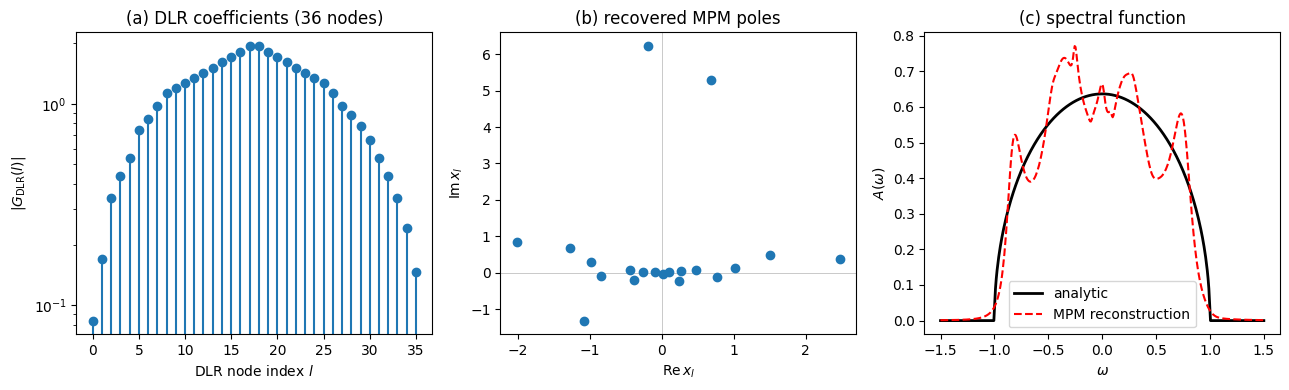

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# (a) DLR coefficient sparsity
coefs = np.abs(g.data[:, 0, 0])
axes[0].stem(np.arange(len(coefs)), coefs)
axes[0].set_yscale("log")
axes[0].set_xlabel("DLR node index $l$")
axes[0].set_ylabel("$|G_{\\mathrm{DLR}}(l)|$")
axes[0].set_title(f"(a) DLR coefficients ({len(coefs)} nodes)")

# (b) recovered poles
axes[1].axhline(0.0, color="0.7", lw=0.5)
axes[1].axvline(0.0, color="0.7", lw=0.5)
axes[1].plot(res.pole_location.real, res.pole_location.imag, "o")
axes[1].set_xlabel(r"$\mathrm{Re}\,x_l$")
axes[1].set_ylabel(r"$\mathrm{Im}\,x_l$")
axes[1].set_title("(b) recovered MPM poles")

# (c) reconstructed spectrum
axes[2].plot(omega, rho_analytic(omega), "k-", lw=2, label="analytic")
axes[2].plot(omega, A_recon, "r--", label="MPM reconstruction")
axes[2].set_xlabel(r"$\omega$")
axes[2].set_ylabel(r"$A(\omega)$")
axes[2].legend()
axes[2].set_title("(c) spectral function")

plt.tight_layout()
plt.show()

## Sanity check

The recovered spectrum should match the analytic semicircle inside the
support and integrate to ~1 (the Bethe-lattice DOS is normalized).

In [6]:
domega = (omega[-1] - omega[0]) / (len(omega) - 1)
print(f"integrated reconstructed weight: {A_recon.sum() * domega:.4f}  (should be ~1)")

integrated reconstructed weight: 0.9945  (should be ~1)
